# clustering

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import clustering

ds =  xr.load_dataset("genes_tpms_white_pauli_JN_BK_mean.nc")

ds["tpm"] = np.log2(ds.tpm+1)
ds["tpm"] = ds.tpm.mean(dim="source")
ds["tpm"] = (ds.tpm - ds.tpm.min("time")) /( ds.tpm.max("time") - ds.tpm.min("time"))

#ds["tpm"] = (ds["tpm"] - ds["tpm"].mean("time")) / ds["tpm"].std("time")


In [ ]:
ds = xr.load_dataset("genes_tpms_white_pauli_JN_BK_mean.nc")
#data = data.where((data.tpm > 0 ).any(dim=("time")), drop=True)
ds = ds.sel(source = ['BK', 'White'])

In [12]:
mask = ds.tpm.max(dim=["time", "source"], skipna=True) >= 5
ds.sel(ensembl_gene_id=mask)

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 21542, time: 50, source: 2)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'White et al.'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan 2.213 ... 10.25
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

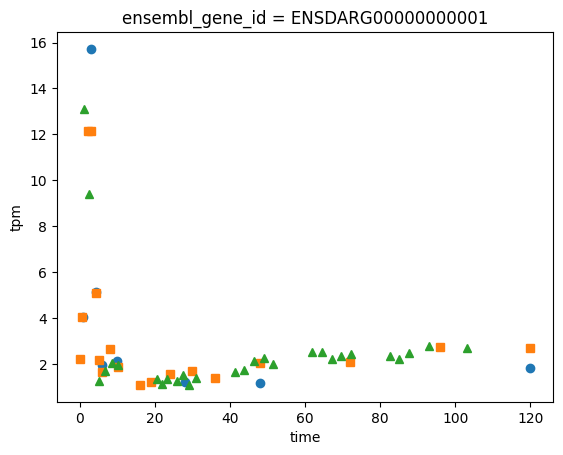

In [ ]:
ds.sel(source="Pauli", drop=True).sel(ensembl_gene_id="ENSDARG00000000001").tpm.plot.line("o")
ds.sel(source='White', drop=True).sel(ensembl_gene_id="ENSDARG00000000001").tpm.plot.line("s")
ds.sel(source='BK', drop=True).sel(ensembl_gene_id="ENSDARG00000000001").tpm.plot.line("^")

In [80]:
pd.read_csv("../clustering/results/gene_cluster_annotation.csv")

,ensembl_gene_id,supercluster,subcluster
0,ENSDARG00000000001,0,0
1,ENSDARG00000000002,1,0
2,ENSDARG00000000018,0,-1
3,ENSDARG00000000019,0,0
4,ENSDARG00000000068,0,0
...,...,...,...
30270,ENSDARG00000117823,1,0
30271,ENSDARG00000117824,1,0
30272,ENSDARG00000117825,1,1
30273,ENSDARG00000117826,0,0


In [87]:
xr.open_dataset("../clustering/results/gene_cluster_annotation.nc").subcluster

<xarray.DataArray 'subcluster' (ensembl_gene_id: 30275)>
[30275 values with dtype=int32]
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...

In [3]:
np.arange(3)

array([0, 1, 2])

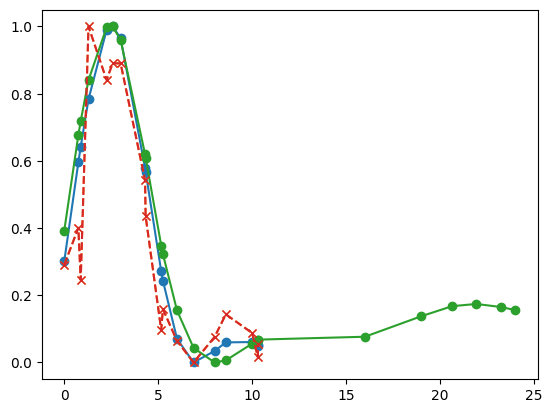

In [6]:
t_end = 12
a = xr.load_dataset(f"C:/Users/mgrho/Expression_baseline_models/clustering/results/gene_trajectories_{t_end}.nc")
a = xr.load_dataset(f"C:/Users/mgrho/Expression_baseline_models/clustering/results/normalized_trajectories_{t_end}.nc")
#xr.load_dataarray("C:/Users/mgrho/Expression_baseline_models/clustering/fuzzy_membership.nc")
ds = ds.sel(time=slice(0, t_end))

gene_id = "ENSDARG00000000151"
plt.plot(a.time, a.sel(ensembl_gene_id=gene_id).trajectory, "o-")
plt.plot(ds.time, ds.tpm.sel(ensembl_gene_id=gene_id), "x--")


t_end = 24
a = xr.load_dataset(f"C:/Users/mgrho/Expression_baseline_models/clustering/results/normalized_trajectories_{t_end}.nc")
ds = ds.sel(time=slice(0, t_end))

gene_id = "ENSDARG00000000151"
plt.plot(a.time, a.sel(ensembl_gene_id=gene_id).trajectory, "o-")
plt.plot(ds.time, ds.tpm.sel(ensembl_gene_id=gene_id), "x--")

In [105]:
y = ds.tpm
y = np.log2(y + 1)
y1 = (y - y.mean(dim=("time", ))) / y.std(dim=("time", ))
y2 = (y - y.mean(dim=("time", "source"))) / y.std(dim=("time", "source"))

y1 = (ds["tpm"] - ds["tpm"].mean(dim=("time", ))) / ds["tpm"].std(dim=("time",))
y2 = (ds["tpm"] - ds["tpm"].mean(dim=("time", "source"))) / ds["tpm"].std(dim=("time", "source"))

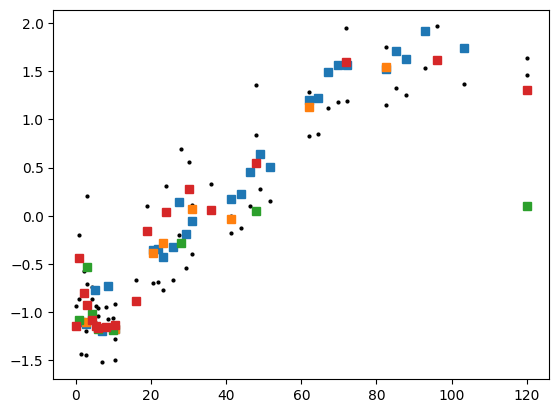

In [ ]:
plt.plot(y1.time, y1.sel(ensembl_gene_id="ENSDARG00000000002"), "ko", ms=2)
plt.plot(y2.time, y2.sel(ensembl_gene_id="ENSDARG00000000002"), "s")
plt.legend()

<xarray.DataArray 'tpm' (time: 50, ensembl_gene_id: 36570, source: 4)>
array([[[        nan,         nan,         nan, -0.14684951],
        [        nan,         nan,         nan, -1.47382714],
        [        nan,         nan,         nan, -2.87363414],
        ...,
        [        nan,         nan,         nan, -0.27471298],
        [        nan,         nan,         nan,  0.44703991],
        [        nan,         nan,         nan, -0.31575379]],

       [[        nan,         nan,         nan,  0.78544295],
        [        nan,         nan,         nan, -0.05064841],
        [        nan,         nan,         nan, -1.69352678],
        ...,
        [        nan,         nan,         nan, -0.27471298],
        [        nan,         nan,         nan,  0.493609  ],
        [        nan,         nan,         nan, -0.31575379]],

       [[        nan,         nan,  0.78015814,         nan],
        [        nan,         nan, -1.24837468,         nan],
        [        nan,         nan, -0.18787583,         nan],
        ...,
...
        ...,
        [        nan,         nan,         nan,  4.60556933],
        [        nan,         nan,         nan,  1.31372661],
        [        nan,         nan,         nan,  5.91849662]],

       [[ 0.14859696,         nan,         nan,         nan],
        [ 1.27844549,         nan,         nan,         nan],
        [-1.16943864,         nan,         nan,         nan],
        ...,
        [ 0.15887781,         nan,         nan,         nan],
        [-0.52823195,         nan,         nan,         nan],
        [ 0.53469873,         nan,         nan,         nan]],

       [[        nan,         nan, -0.40599409,  0.14983363],
        [        nan,         nan,  0.45038194,  1.10938362],
        [        nan,         nan, -1.555526  , -1.12906869],
        ...,
        [        nan,         nan,  2.77939758, -0.27471298],
        [        nan,         nan,  0.1931736 , -0.74160947],
        [        nan,         nan,  3.07147461, -0.31575379]]])
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'

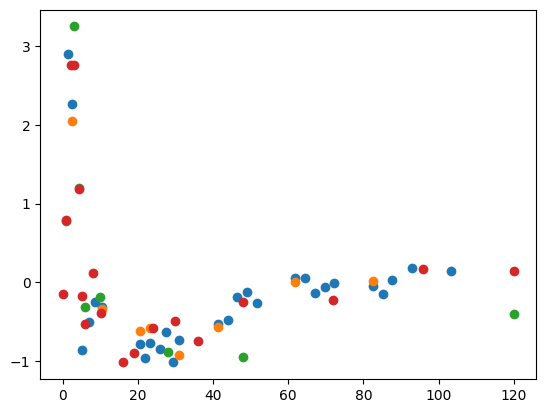

In [92]:
y = ds.tpm
y = np.log2(y + 1)
y = (y - y.mean(dim=("time", "source"))) / y.std(dim=("time", "source"))

plt.plot(y.time, y.sel(ensembl_gene_id="ENSDARG00000000001"), "o")
y

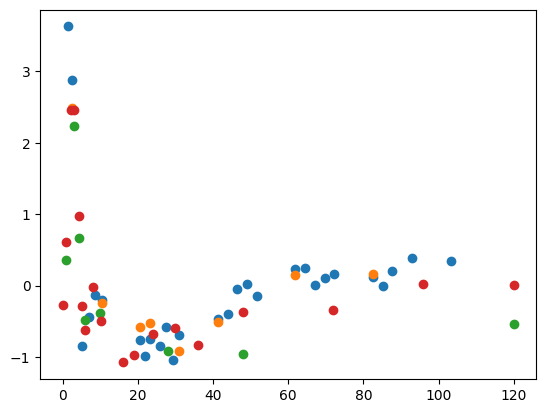

In [84]:
plt.plot(y.time, y.sel(ensembl_gene_id="ENSDARG00000000001"), "o")

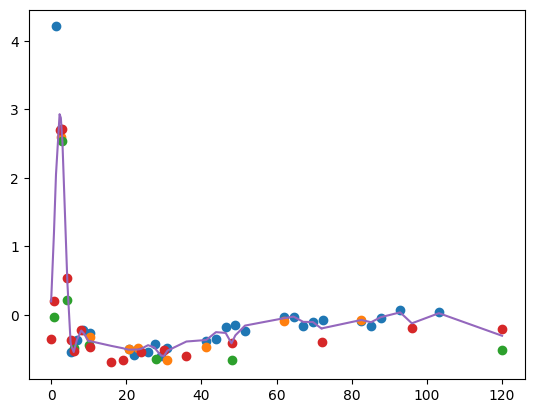

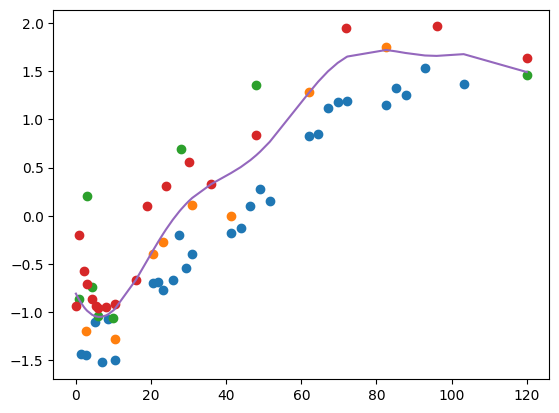

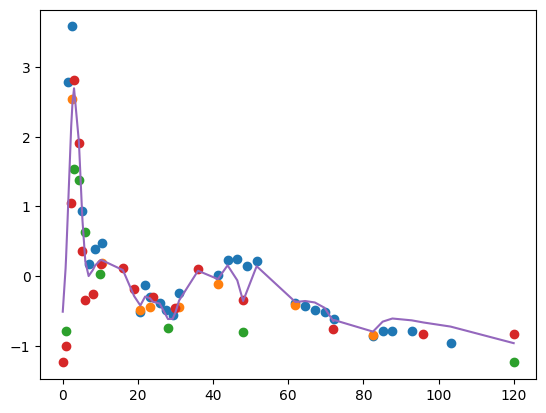

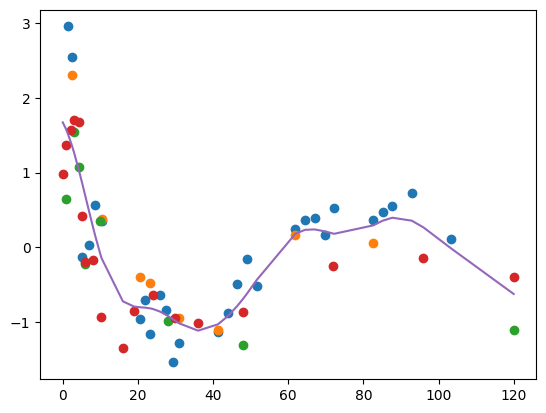

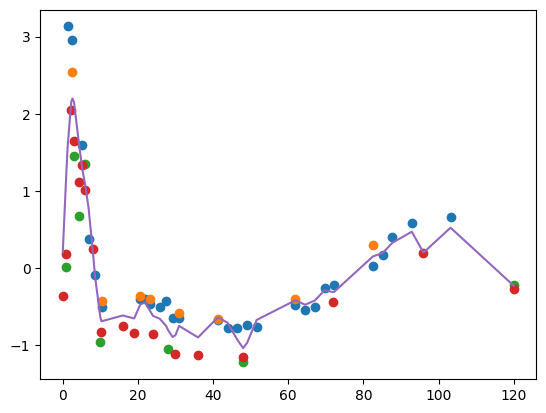

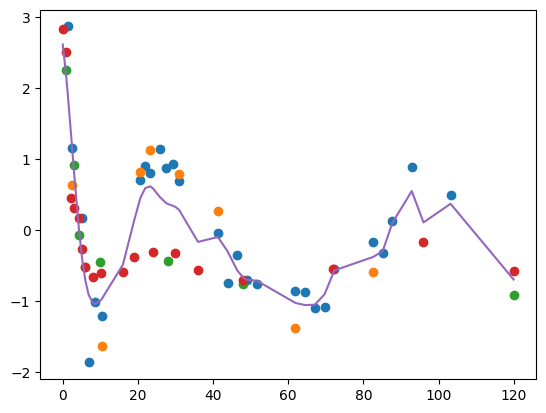

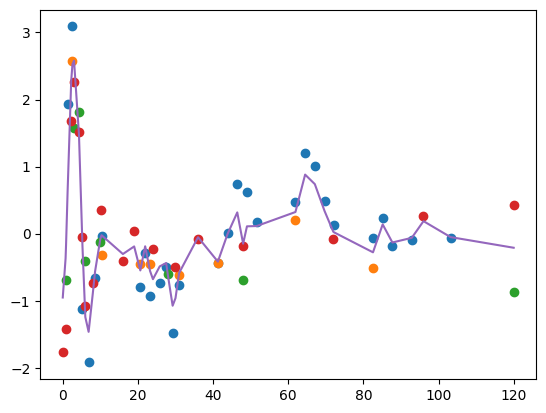

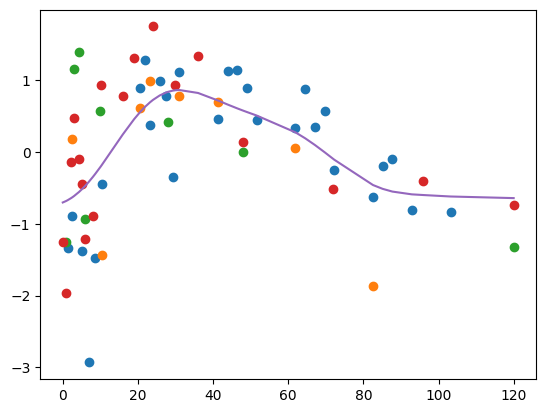

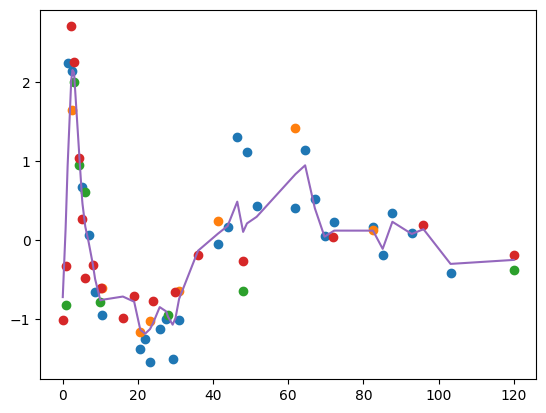

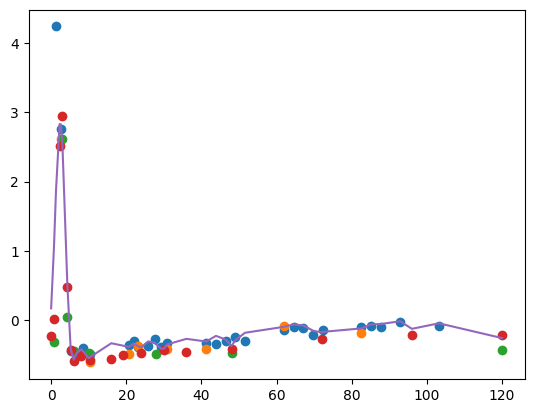

In [64]:
for i in range(10):
    plt.subplots()
    plt.plot(ds.time, ds.tpm.sel(ensembl_gene_id=ds.ensembl_gene_id.values[i]), "o")
    plt.plot(ds.time, c["curves"][i])

## K-means

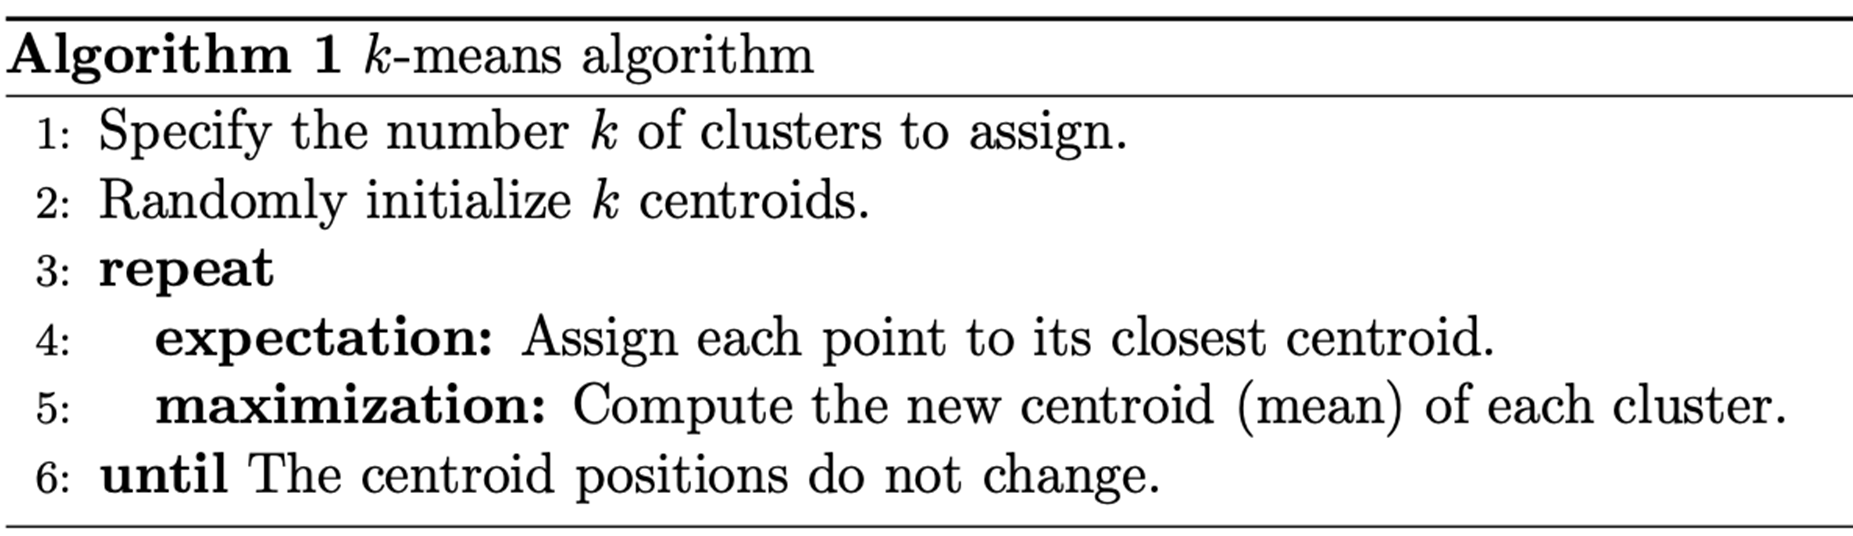

In [1]:
# https://realpython.com/k-means-clustering-python/
# https://towardsdatascience.com/create-your-own-k-means-clustering-algorithm-in-python-d7d4c9077670/

In [11]:
def kmean_clustering(data1, data_name="White", palette="Set1", k_cluster=None, t_end=120):

    import xarray as xr
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import zscore
    from sklearn.metrics.pairwise import cosine_distances


    def filter_dataset(ds):
        import xarray as xr
        import pandas as pd
        
        num_positive = (ds['y'] > 0).sum(dim='time')
        max_tpm = ds['y'].max(dim='time')
        #genes_to_keep = (num_positive >= 3) & (max_tpm > 1)
        genes_to_keep = (num_positive >= 6) & (max_tpm > 1)
        ds_filtered = ds.sel(ensembl_gene_id=genes_to_keep)

        return ds_filtered

    ds = filter_dataset(data1).copy().sel(time=slice(0, t_end))
    expr = ds.y

    # Hestilow
    expr_scaled = (expr - expr.mean("time")) / abs(expr - expr.mean("time")).max("time")

    # mix-max normalisation
    #expr_scaled = (expr - expr.min("time")) / (expr.max("time") - expr.min("time"))

    #expr_scaled = expr_scaled.fillna(0)

    X = expr_scaled.transpose('ensembl_gene_id', 'time').values
    """
    X_centered = X - X.mean(axis=1, keepdims=True)
    norm = np.linalg.norm(X_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1
    X_norm = X_centered / norm
    """
    X_norm = X

    if X_norm.shape[0] == 0:
        raise ValueError(f"No genes passed the filtering step for cluster {k_cluster}")


    '''
    --------------------
    Elbow method
    --------------------
    '''
    # from https: //medium.com/ leukemiaairesearch/clustering-techniques-with-gene-expression-data-4b35a04f87d5
    sse = []
    kmeans_kwargs = { "init": "random",  "n_init": 10, "max_iter": 300, "random_state": 1}
    k_range = range(2, 15)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        #kmeans.fit(expr_scaled)
        kmeans.fit(X_norm)
        sse.append(kmeans.inertia_)

    plt.plot(k_range, sse, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of squared distances')
    plt.title('Elbow Method')
    plt.grid()
    plt.savefig(f"../figures/elbow_method_{data_name}.png")
    plt.show()

    import numpy as np
    ks = np.array(list(k_range))
    sse_arr = np.array(sse)
    # line between first and last points
    p1 = np.array([ks[0], sse_arr[0]])
    p2 = np.array([ks[-1], sse_arr[-1]])
    # compute distance to line
    distances = []
    for k, s in zip(ks, sse_arr):
        p = np.array([k, s])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    elbow_k = ks[np.argmax(distances)]
    print("Elbow at k =", elbow_k)


    # Silhouette scores
    '''
    sil_scores = []
    for k in k_range:
        labels = KMeans( n_clusters=k, n_init=20, random_state=11).fit_predict(X_norm)
        sil_scores.append(silhouette_score(X_norm, labels,  metric="cosine"))

    plt.plot(k_range, sil_scores, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Silhouette Method')
    plt.grid()
    plt.savefig(rf"../figures/silhuette_method_{data_name}.png")
    plt.show()
    '''

    ''' 
    -------------------------------
    k-means clustering
    -------------------------------
    '''

    k = k_cluster if k_cluster else elbow_k
    kmeans = KMeans(init="k-means++", n_clusters=k, random_state=1, n_init=50)
    #labels = kmeans.fit_predict(X)
    labels = kmeans.fit_predict(X_norm)

    # Add cluster labels as a new variable in the Dataset
    ds['cluster'] = (('ensembl_gene_id',), labels)
    cluster_medians = (expr_scaled.groupby(ds.cluster).mean(dim='ensembl_gene_id')    )
    cluster_std = (expr_scaled.groupby(ds.cluster).std(dim='ensembl_gene_id')    )

    # sort cluster centers by time of maximum expression
    # index of max expression along time
    peak_time_idx = cluster_medians.argmax(dim="time")
    peak_times = cluster_medians.time.values[peak_time_idx.values]
    new_order = np.argsort(peak_times)

    # mapping: old_label -> new_label
    label_map = {old: new for new, old in enumerate(new_order)}
    new_labels = np.array([label_map[c] for c in ds.cluster.values])
    ds['cluster'] = (('ensembl_gene_id',), new_labels)

    cluster_medians = cluster_medians.sel(cluster=new_order)
    cluster_medians = cluster_medians.assign_coords(cluster=np.arange(len(new_order)))
    cluster_std = cluster_std.sel(cluster=new_order)
    cluster_std = cluster_std.assign_coords(cluster=np.arange(len(new_order)))
    ds.to_netcdf(f"genes_clustered_{data_name}.nc")

    values = ds.cluster.values
    unique, counts = np.unique(values, return_counts=True)

    cluster_counts = dict(zip(unique, counts))
    print(cluster_counts)

    ''' 
    -------------------------------
    check clustering metrics
    -------------------------------
    '''

    # check silhouette score: higher -> better (~1)
    labels = kmeans.labels_
    print("labels:", labels)
    sil = silhouette_score(X_norm, labels)
    print("Silhouette score:", sil)

    # higher -> better
    from sklearn.metrics import calinski_harabasz_score
    ch = calinski_harabasz_score(X_norm, labels)
    print("Calinski–Harabasz score:", ch)

    # lower -> better
    from sklearn.metrics import davies_bouldin_score
    db = davies_bouldin_score(X_norm, labels)
    print("Davies–Bouldin score:", db)

    from sklearn.metrics import adjusted_rand_score
    labels_full = labels.copy()
    scores = []
    for i in range(20):
        idx = np.random.choice(len(X_norm), int(0.8*len(X_norm)), replace=True)
        km_sub = KMeans(n_clusters=k, n_init=20).fit(X_norm[idx])
        ar = adjusted_rand_score(labels_full[idx], km_sub.labels_)
        scores.append(ar)
    print("Cluster stability (mean ARI):", np.mean(scores))

    ''' 
    -------------------------------
    plot profiles - trajectories
    -------------------------------
    '''

    fig, ax = plt.subplots(figsize=(8,5))
    c = sns.color_palette(palette, k)
    for i in range(k):
        #ax.plot(cluster_means['time'], cluster_means.sel(cluster=i), label=f'Cluster {i}', c=c[i])
        mean = cluster_medians.sel(cluster=i)
        std = cluster_std.sel(cluster=i)
        ax.plot(cluster_medians['time'], mean, lw=2, label=f'{i}', c=c[i], marker="o", ms=2)
        ax.fill_between(cluster_medians['time'], y1 = mean-std, y2=mean+std, lw=0.5, color=c[i], alpha=0.1)
    #ax.set(title='Mean gene expression clusters', xlabel='time (hpf)',ylabel='Expression (log2(TPM + 1))')
    ax.set(title='Mean gene expression clusters', xlabel='time (hpf)',ylabel='normalised expression')
    ax.legend(title="Cluster", loc=(1.01, 0.3), frameon=False)
    #ax.set_xlim(0, 10)
    plt.tight_layout()
    plt.savefig(f"../figures/kmeans_expression_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()

    name = ["SD","TU pre-ZGA" ,"TU post-ZGA","SU ZGA" ,"SU post-ZGA"]


    #fig, ax = plt.subplots(1,5, figsize=(15, 2.5), sharey=True)
    fig, ax = plt.subplots(5,1, figsize=(4, 12), sharey=True, sharex=True)
    c = sns.color_palette(palette, k)
    for i in range(k):
        #ax.plot(cluster_means['time'], cluster_means.sel(cluster=i), label=f'Cluster {i}', c=c[i])
        mean = cluster_medians.sel(cluster=i)
        std = cluster_std.sel(cluster=i)
        ax[i].plot(cluster_medians['time'], mean, lw=2, label=f'{i}', c=c[i], marker="o", ms=2)
        #ax[i].fill_between(cluster_medians['time'], y1 = mean-std, y2=mean+std, lw=0.5, color=c[i], alpha=0.1)
    #ax.set(title='Mean gene expression clusters', xlabel='time (hpf)',ylabel='Expression (log2(TPM + 1))')
        ax[i].set_ylabel('expression')
        ax[i].set_title(f'Cluster {i} - {name[i]}', fontsize=16)
    #ax.legend(title="Cluster", loc=(1.01, 0.3), frameon=False)
    #ax.set_xlim(0, 10)
    ax[-1].set_xlabel('time (hpf)')
    plt.tight_layout()
    plt.savefig(f"../figures/kmeans_expression_cluster_{data_name}_subplots.png", dpi=300, transparent=True)
    plt.show()

    ''' 
    -------------------------------
    plot profiles - heatmap
    -------------------------------
    '''
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.colors import ListedColormap

    # Sorted clusters
    sorted_genes = np.argsort(ds['cluster'].values)
    #print("Sorted genes:", sorted_genes)
    expr_plot = expr_scaled.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = ds['cluster'].values[sorted_genes]
    print("Sorted clusters:", sorted_clusters)

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]     # find end indices
    centers = (start_idx + end_idx) / 2     # compute vertical centers for labels

    # colormap for clusters
    #k = int(sorted_clusters.max() + 1)
    cluster_cmap = ListedColormap(sns.color_palette(palette, k))

    fig = plt.figure(figsize=(8,7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    #ax_bar.set_ylabel("Genes (sorted by cluster)")

    # Add cluster numbers
    for c, y in zip(unique_clusters, centers):
        ax_bar.text(
            0.05, y,
            str(c),
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='black',
            transform=ax_bar.transData
        )

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(
        expr_plot.values.T,
        cmap='Spectral_r',
        yticklabels=False,
        xticklabels=expr_plot.time.values,
        ax=ax,
        #cbar_kws={'label': 'Z-score', 'shrink': 0.5, 'pad': 0.02 }
        cbar_kws={'label': 'normalised expression', 'shrink': 0.5, 'pad': 0.02 }
    )
    ax.set_title(f'Gene expression pattern in $D. rerio$', fontsize=16)
    ax.set(xlabel='Time (hpf)', ylabel='')
    ax.tick_params("x", rotation=90)

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)
    plt.tight_layout()
    plt.savefig(f"../figures/heatmap_kmeans_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()

    ## PCA plot
    """
    from sklearn.decomposition import PCA
    import seaborn as sns
    import numpy as np
    import matplotlib.pyplot as plt

    pca = PCA(n_components=5)
    pca_res = pca.fit_transform(X_norm)

    clusters = np.unique(labels)
    print("Clusters:", clusters)
    colors = sns.color_palette(palette, len(clusters))

    fig, ax = plt.subplots(figsize=(6,4))

    for k in clusters:
        idx = labels == k
        ax.scatter(
            pca_res[idx, 0], # PC1
            pca_res[idx, 1], # PC2
            #pca_res[idx, 2], # PC3
            s=2,
            color=colors[k],
            label=f"{k}",
            alpha=0.7
        )

    # centroids
    for k in clusters:
        centroid = pca_res[labels == k].mean(axis=0)
        ax.scatter(
            centroid[0], centroid[1],
            s=50,
            marker='X',
            color=colors[k],
            edgecolor='black',
            linewidth=0.5,
        )

    ax.set_title(f"PCA of expression clusters (k={elbow_k})")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    #ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")

    ax.legend(title="Cluster", markerscale=3, fontsize=8, frameon=False)
    plt.tight_layout()
    plt.savefig(f"../figures/PCA_{data_name}.png")
    plt.show()
    """

    return ds, cluster_medians, X_norm





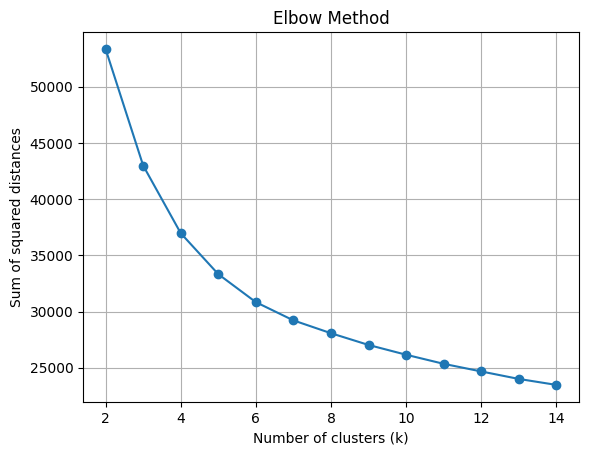

Elbow at k = 5
{0: 3795, 1: 5921, 2: 3771, 3: 3551, 4: 7412}
labels: [0 1 0 ... 2 4 2]
Silhouette score: 0.2791792028044895
Calinski–Harabasz score: 8977.502434819446
Davies–Bouldin score: 1.404942801836923
Cluster stability (mean ARI): 0.9864492439232366


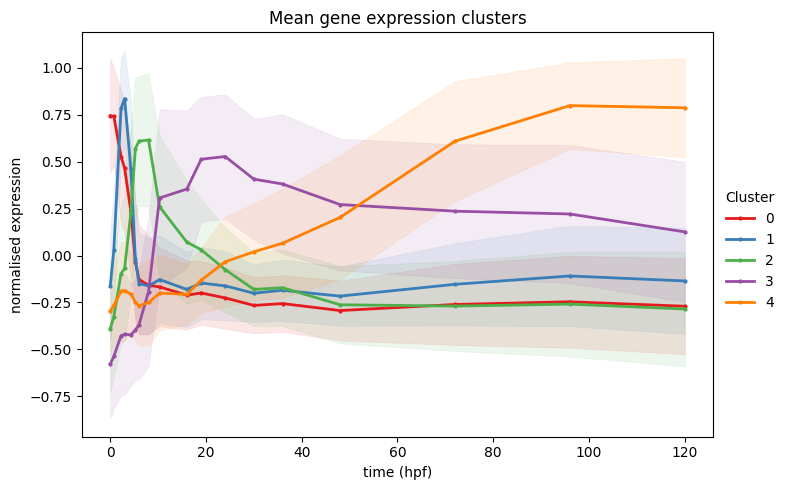

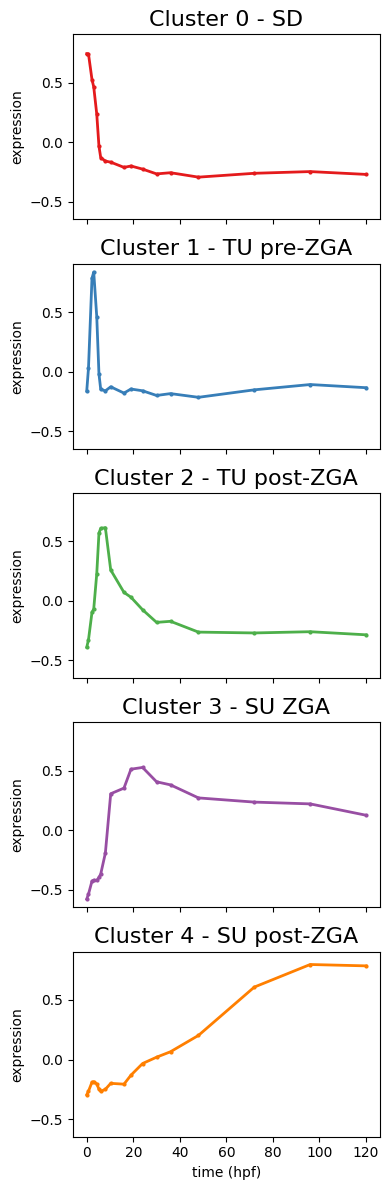

Sorted clusters: [0 0 0 ... 4 4 4]


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7732\1437846079.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


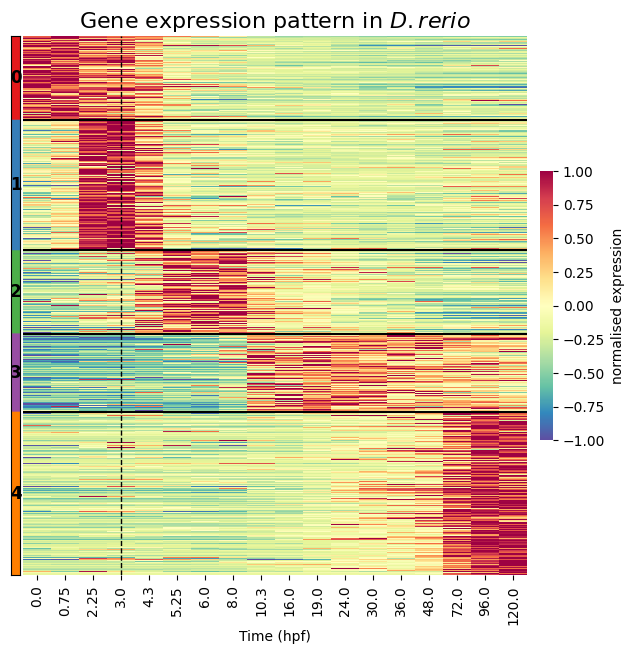

In [12]:
import xarray as xr
data1 = xr.load_dataset("white_dataset_mean.nc").sel(time=slice(0,120))
ds, cluster_medians, X_norm = kmean_clustering(data1,data_name="White_h", palette="Set1")

In [87]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

top_n = 2
representative_genes_corr = {}

for cluster_id in range(5):
    cluster_profile = cluster_medians.sel(cluster=cluster_id).values
    
    corrs = []
    indices = np.where(ds.cluster.values == cluster_id)[0]
    
    for idx in indices:
        gene_profile = X_norm[idx]
        r, _ = pearsonr(gene_profile, cluster_profile)
        corrs.append(r)
    
    corrs = np.array(corrs)
    top_idx = indices[np.argsort(-corrs)[:top_n]]
    
    representative_genes_corr[cluster_id] = ds.ensembl_gene_id.values[top_idx]


representative_genes_corr

{0: array(['ENSDARG00000075354', 'ENSDARG00000012222'], dtype=object),
 1: array(['ENSDARG00000005544', 'ENSDARG00000087424'], dtype=object),
 2: array(['ENSDARG00000100142', 'ENSDARG00000099917'], dtype=object),
 3: array(['ENSDARG00000036299', 'ENSDARG00000098295'], dtype=object),
 4: array(['ENSDARG00000003512', 'ENSDARG00000054848'], dtype=object)}

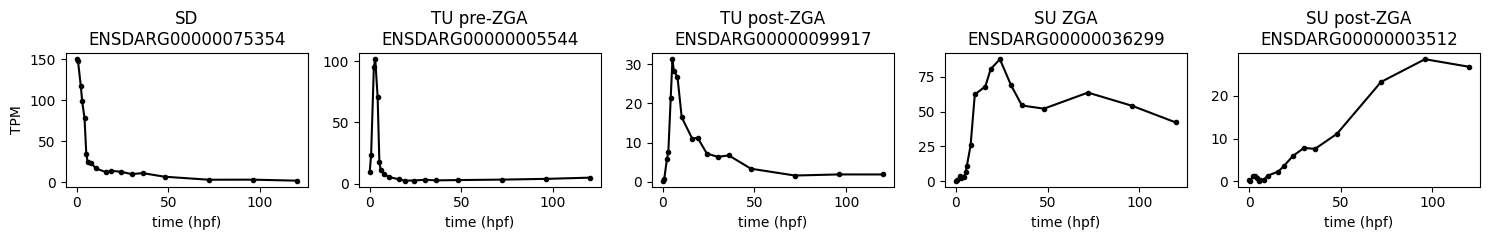

In [93]:
import matplotlib.pyplot as plt
## representative genes
genes = {"SD":representative_genes_corr[0][0],
         "TU pre-ZGA": representative_genes_corr[1][0], 
         "TU post-ZGA": representative_genes_corr[2][1],
         "SU ZGA": representative_genes_corr[3][0],
         "SU post-ZGA": representative_genes_corr[4][0],}
ds1 = data1.y
fig, ax = plt.subplots(1,5, figsize=(15, 2.5))

for i, c in enumerate(genes):
    gene = genes[c]
    ax[i].plot(ds1.time, ds1.sel(ensembl_gene_id=gene), "k", marker=".")
    ax[i].set(title=f"{c}\n{gene}", xlabel="time (hpf)")
ax[0].set(ylabel="TPM")
plt.tight_layout()
#plt.savefig("../figures/representative_genes.png")
plt.show()

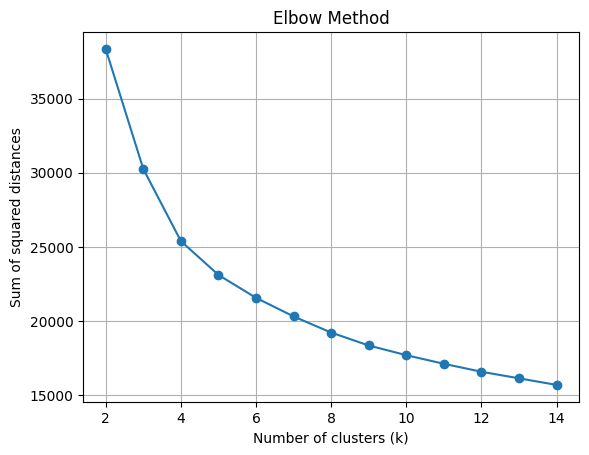

Elbow at k = 5
{0: 3991, 1: 6685, 2: 3642, 3: 3274, 4: 3646}
labels: [0 2 0 ... 3 1 3]
Silhouette score: 0.27144607072525173
Calinski–Harabasz score: 8643.213903354717
Davies–Bouldin score: 1.3679427368847343
Cluster stability (mean ARI): 0.9822325352610708


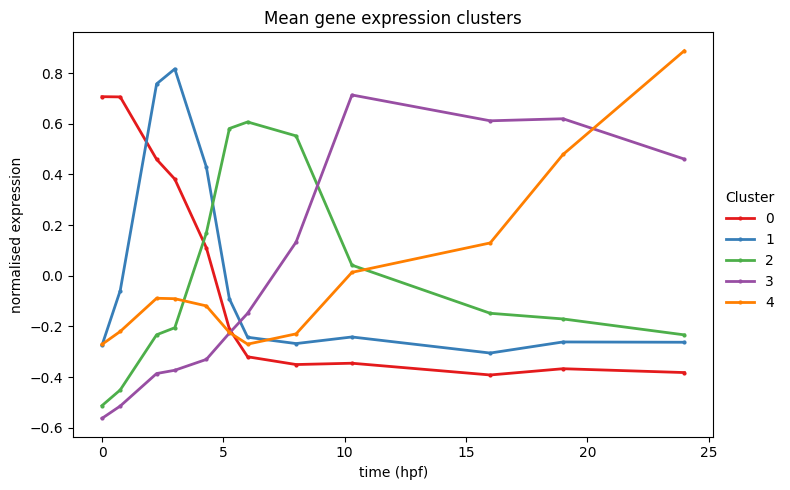

Sorted clusters: [0 0 0 ... 4 4 4]


C:\Users\mgrho\AppData\Local\Temp\ipykernel_23976\514253323.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


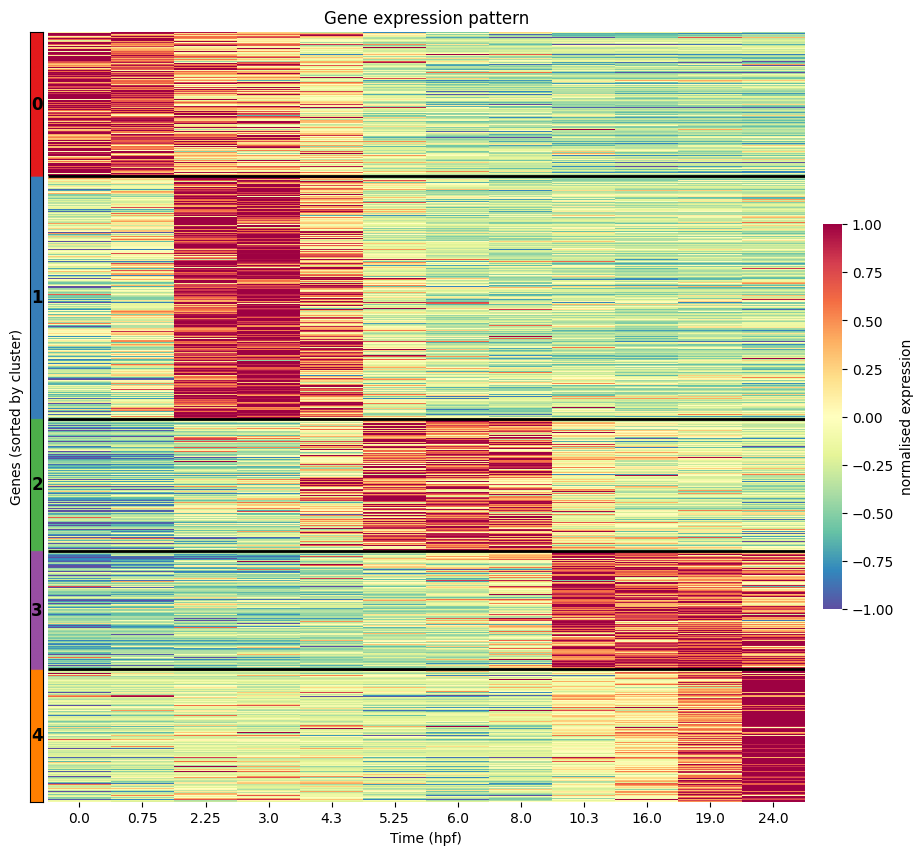

Clusters: [0 1 2 3 4]


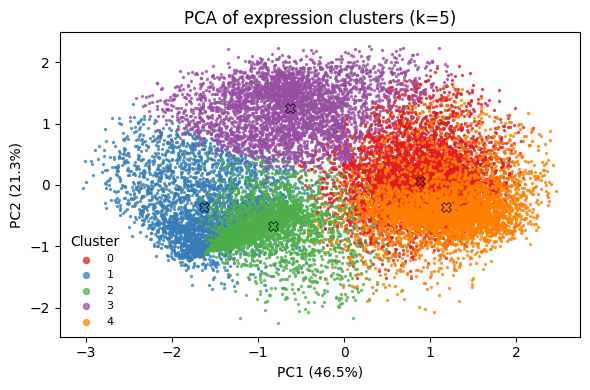

In [2]:
import xarray as xr
data1 = xr.load_dataset("white_dataset_mean.nc").sel(time=slice(0,24))
kmean_clustering(data1, data_name="White_24hpf")

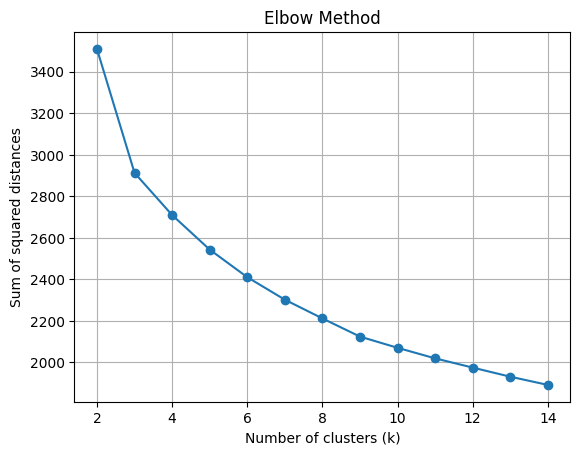

Elbow at k = 5
Silhouette score: 0.17083436339407843
Calinski–Harabasz score: 688.4484968041475
Davies–Bouldin score: 1.7307880491137222
Cluster stability (mean ARI): 0.8651530637114698


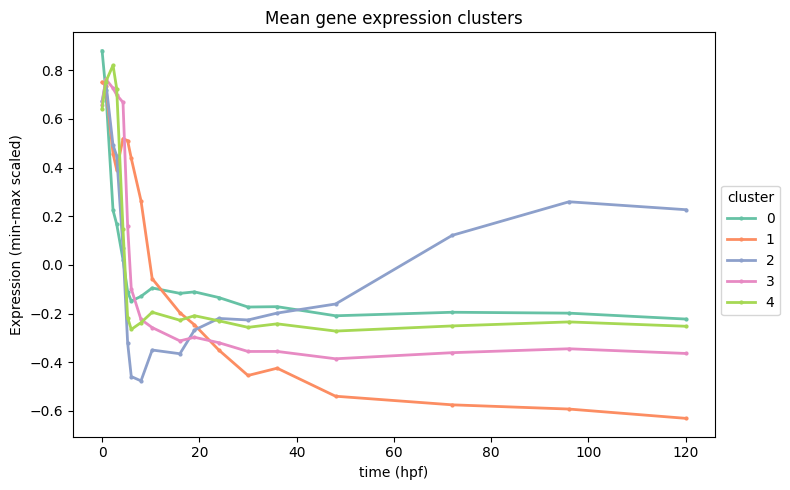

C:\Users\mgrho\AppData\Local\Temp\ipykernel_25496\1953186209.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


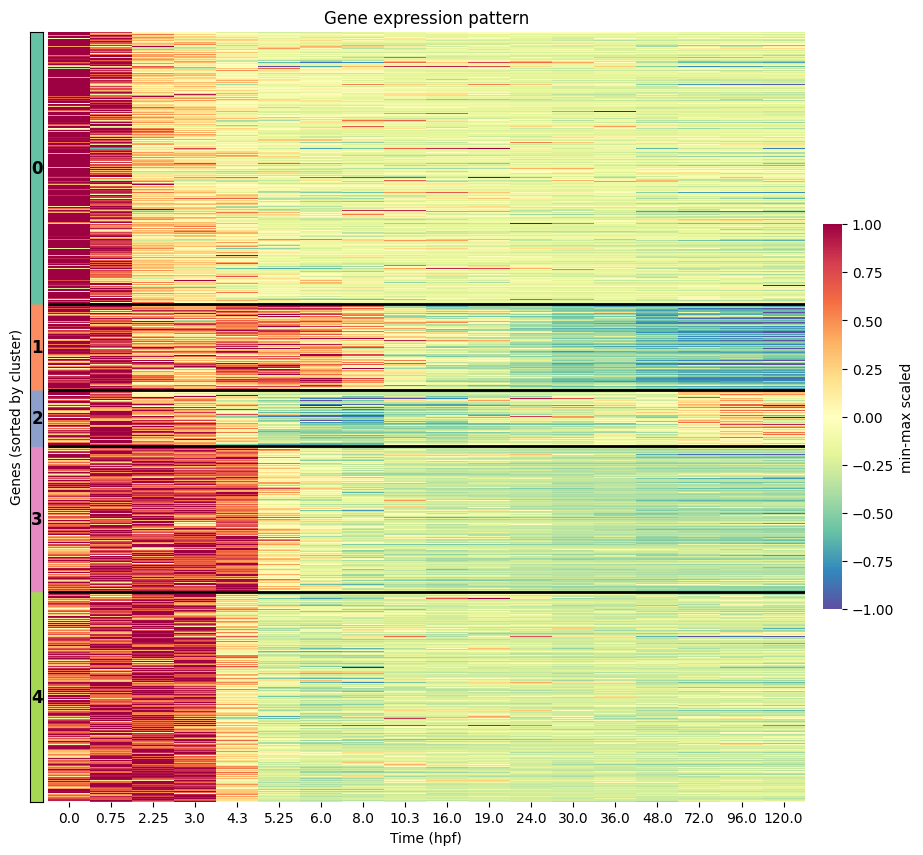

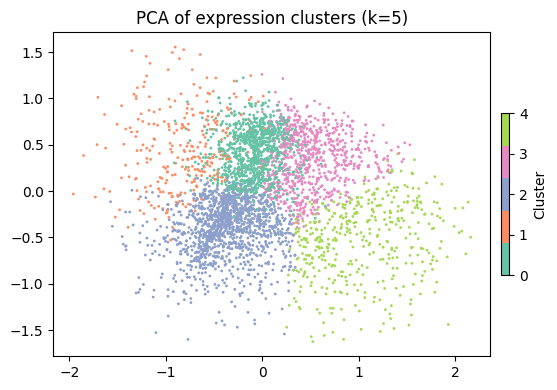

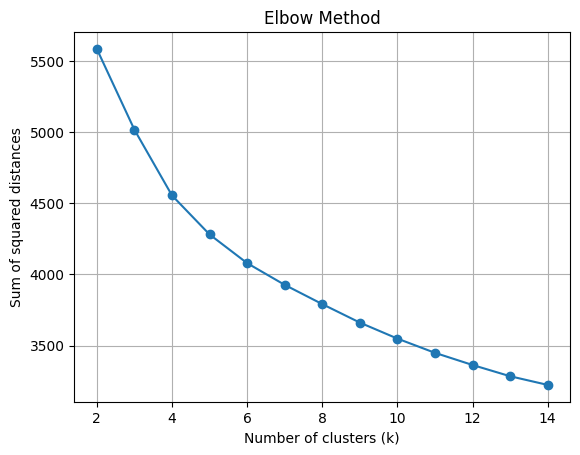

Elbow at k = 6
Silhouette score: 0.12704838244726904
Calinski–Harabasz score: 824.3557116498384
Davies–Bouldin score: 1.8330961571461852
Cluster stability (mean ARI): 0.8804646699440356


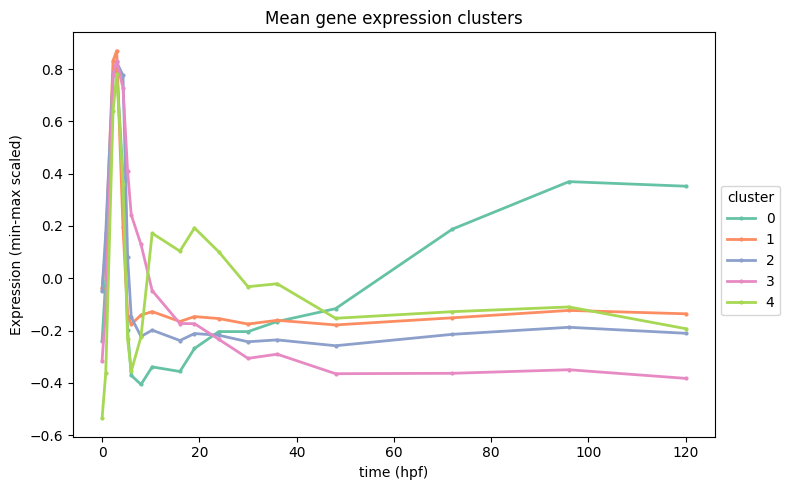

C:\Users\mgrho\AppData\Local\Temp\ipykernel_25496\1953186209.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


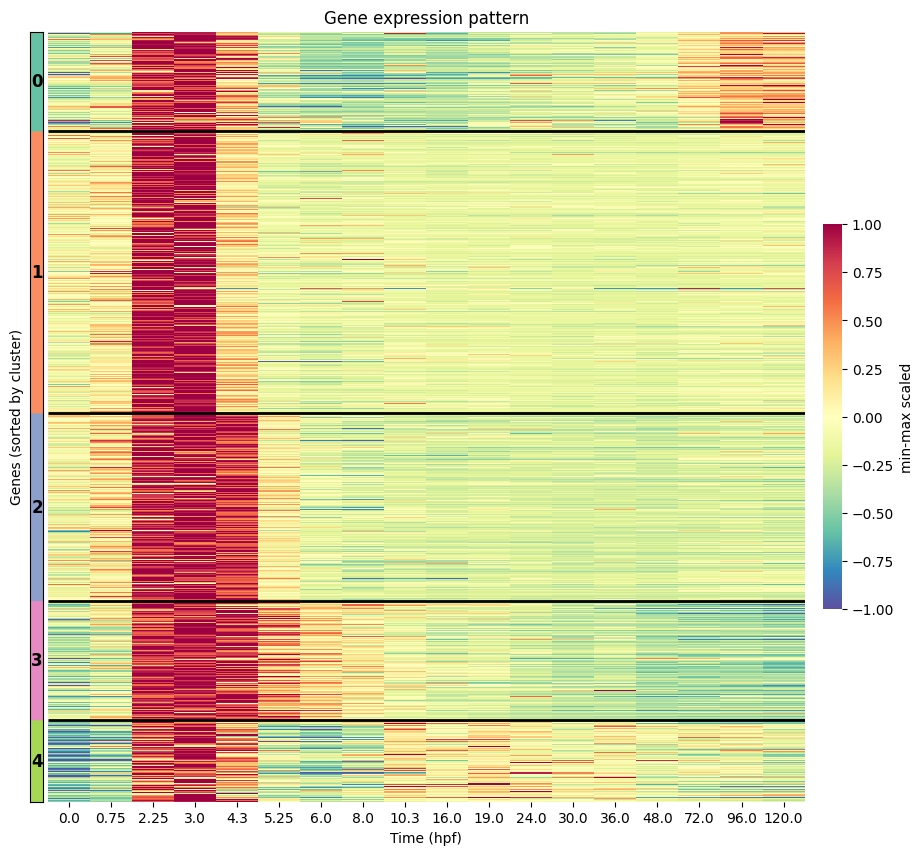

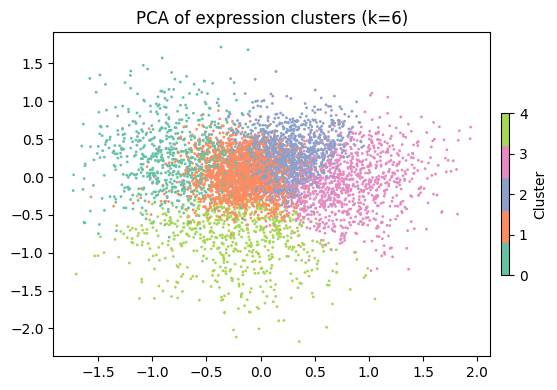

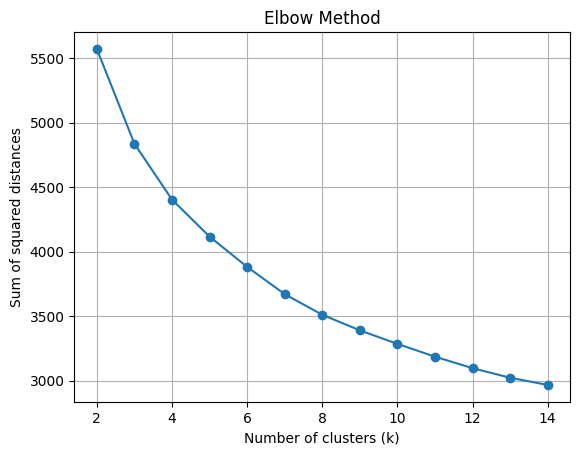

Elbow at k = 6
Silhouette score: 0.14986655268975804
Calinski–Harabasz score: 622.3214524810649
Davies–Bouldin score: 1.7498749974052952
Cluster stability (mean ARI): 0.8496840530709996


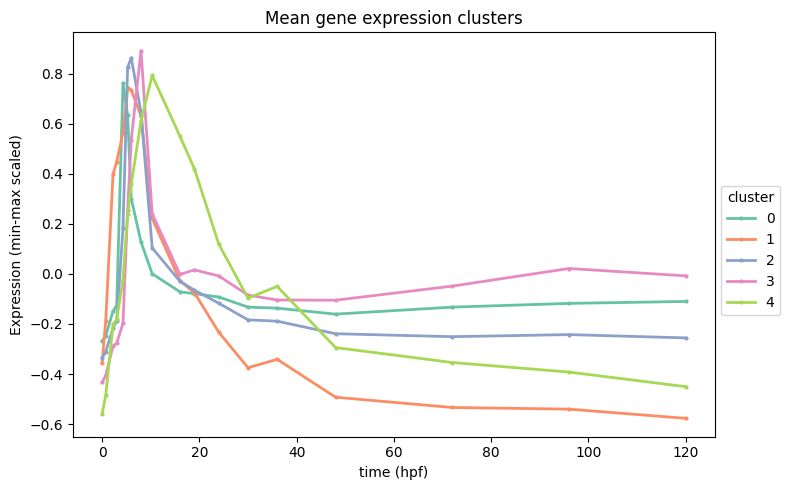

C:\Users\mgrho\AppData\Local\Temp\ipykernel_25496\1953186209.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


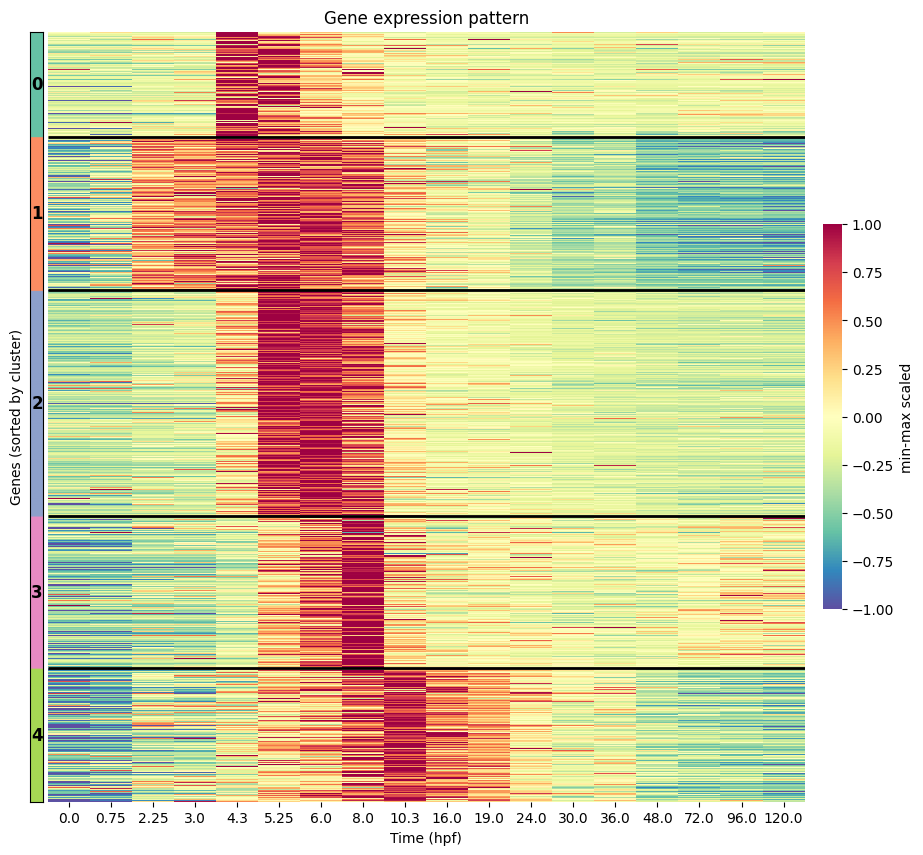

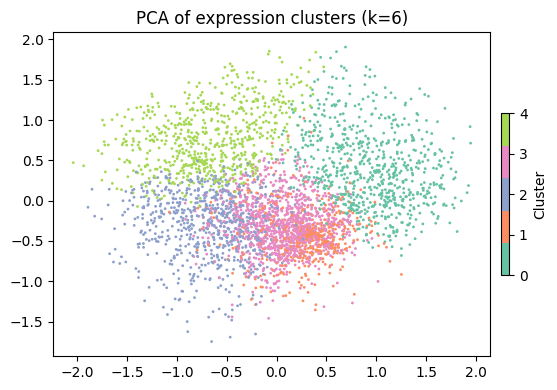

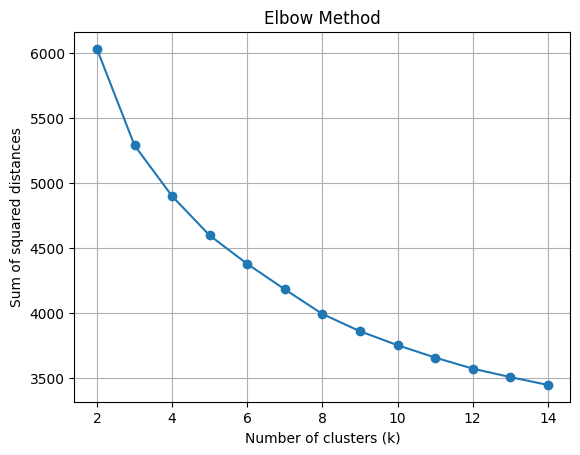

Elbow at k = 6
Silhouette score: 0.1434392262324474
Calinski–Harabasz score: 579.4180801876336
Davies–Bouldin score: 1.8377636961087518
Cluster stability (mean ARI): 0.8896925719459843


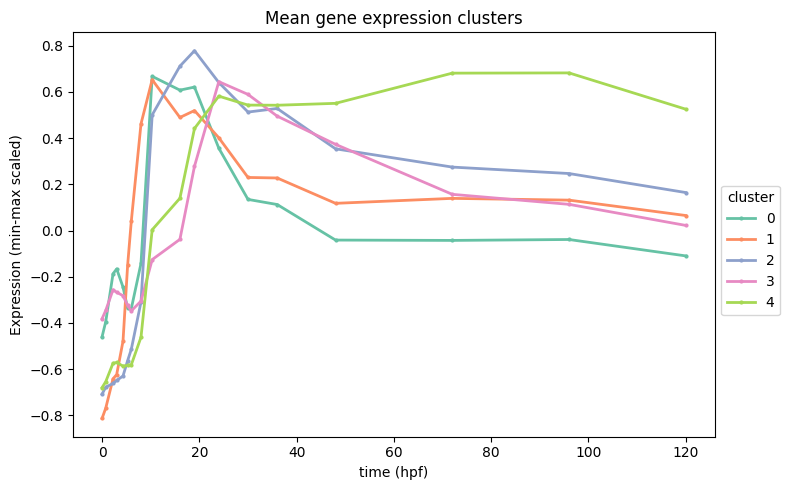

C:\Users\mgrho\AppData\Local\Temp\ipykernel_25496\1953186209.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


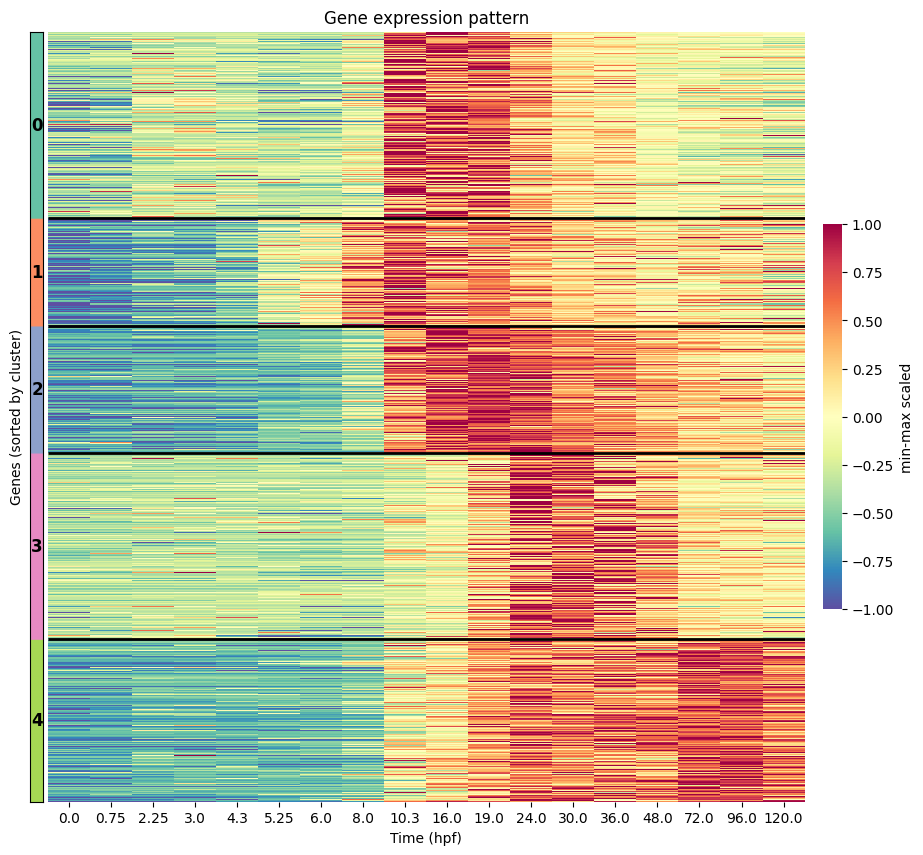

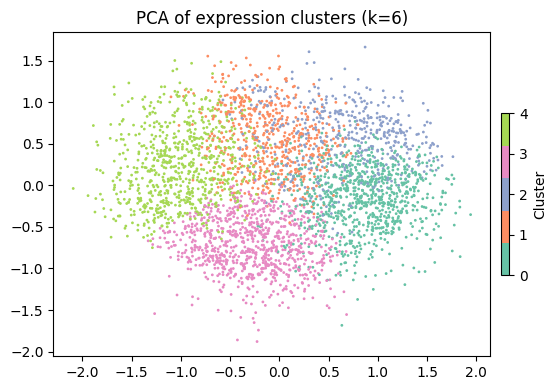

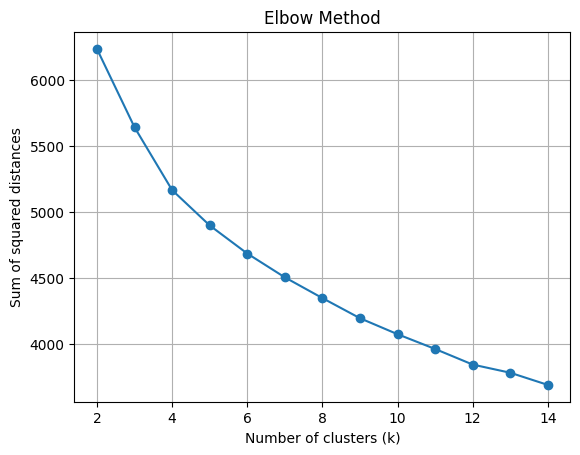

Elbow at k = 6
Silhouette score: 0.1503312748154203
Calinski–Harabasz score: 1105.2164266133786
Davies–Bouldin score: 1.8759662682172664
Cluster stability (mean ARI): 0.9131106312536545


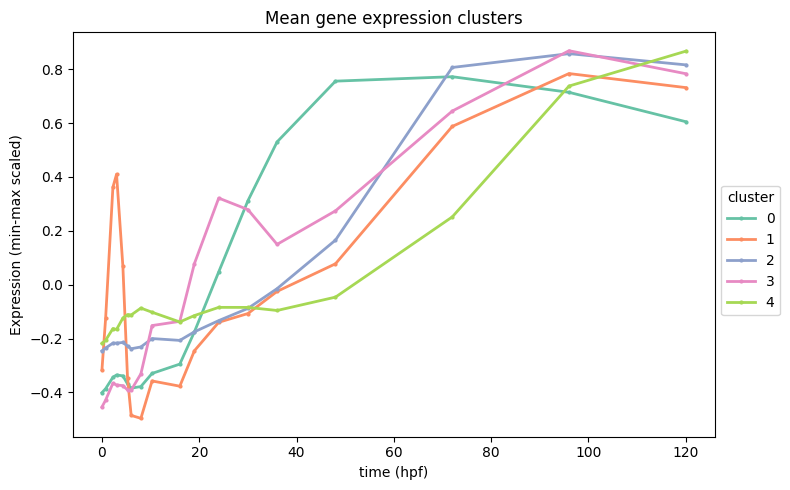

C:\Users\mgrho\AppData\Local\Temp\ipykernel_25496\1953186209.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


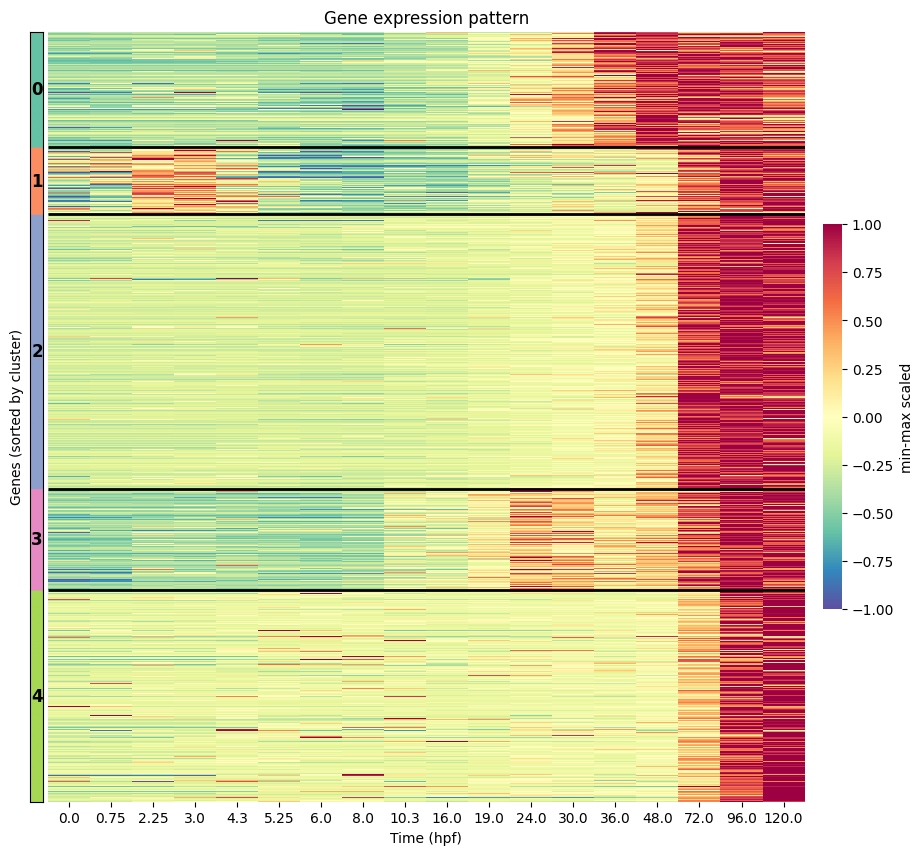

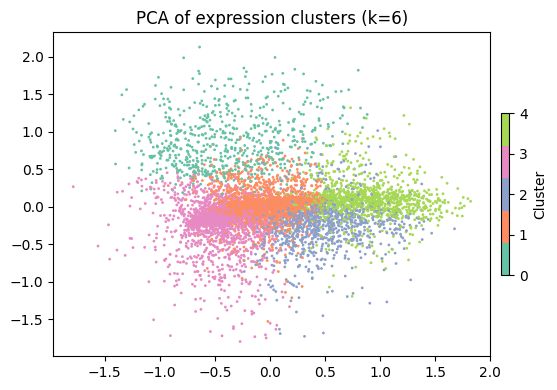

In [7]:
import xarray as xr
import pandas as pd

for k in range(5):
    subcluster = k

    clusters = pd.read_csv("dataset_structure_white_cluster_h.csv")
    selected = clusters.loc[clusters["cluster"] == subcluster, "ensembl_gene_id"].values

    data1 = xr.load_dataset("white_dataset_mean.nc")
    data1 = data1.sel(ensembl_gene_id = selected)

    kmean_clustering(data1, data_name=f"White_cluster{subcluster}_h",  palette="Set2", k_cluster=5)

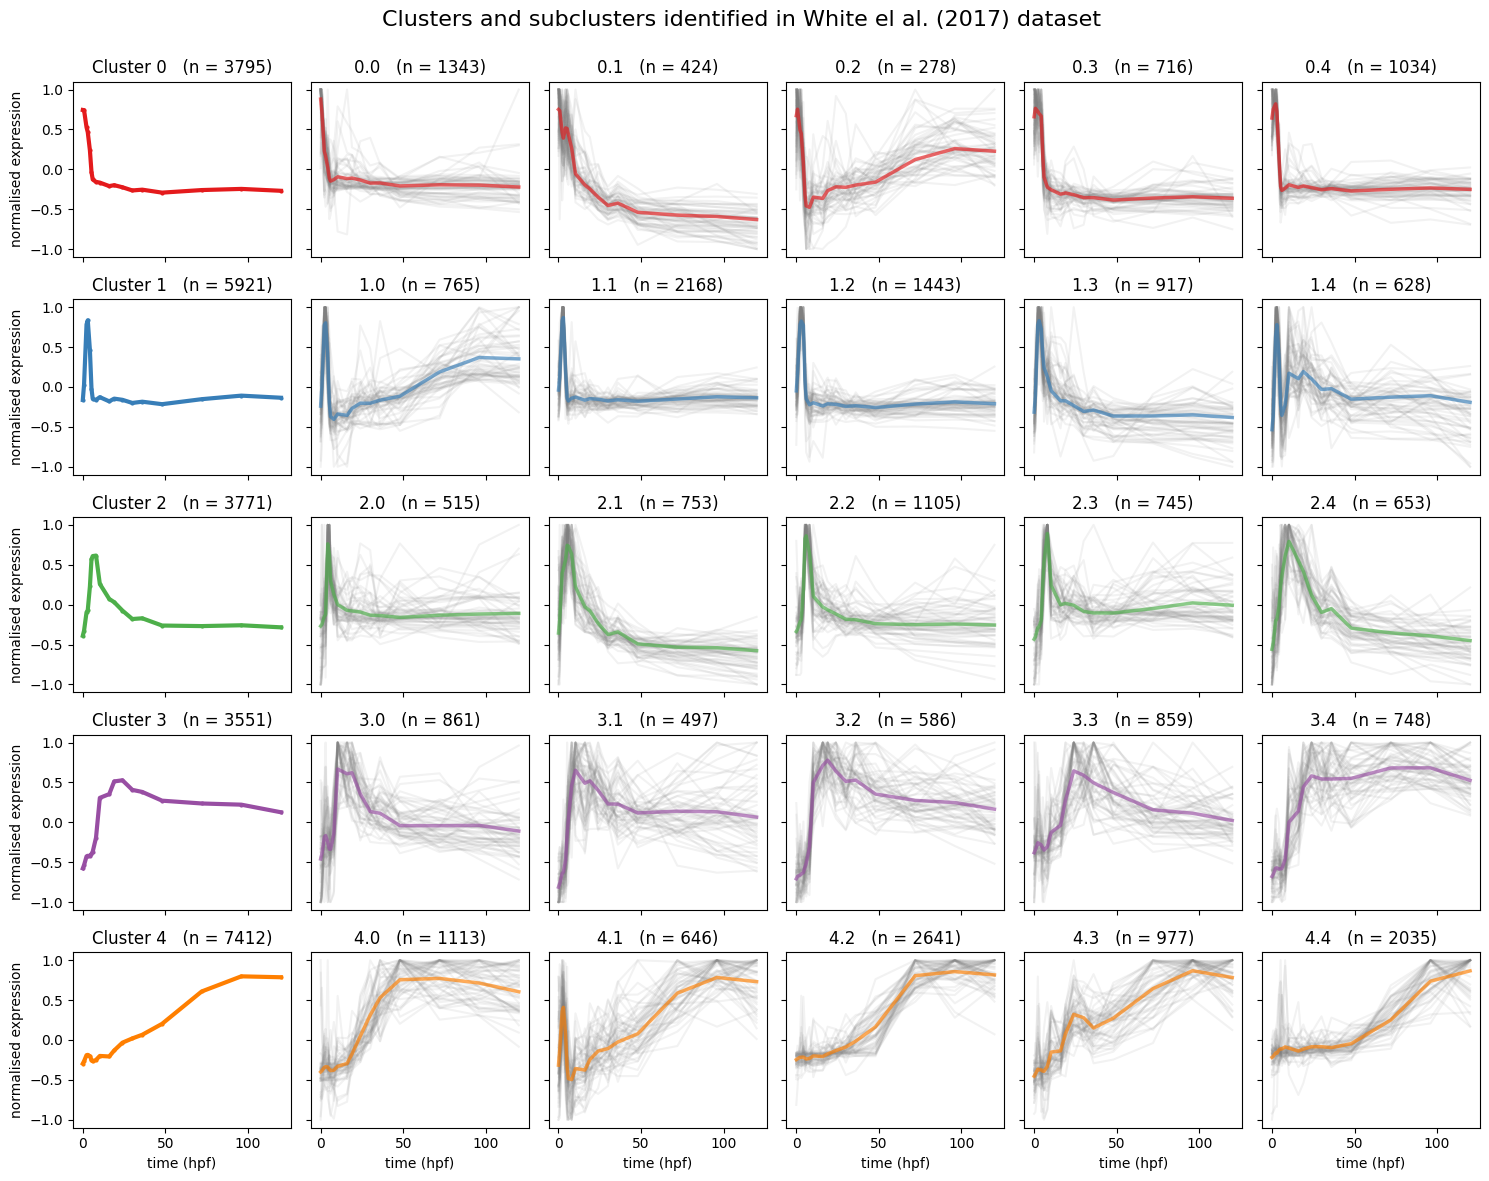

In [3]:
cluster_names = {
    0.0: "SD",
    1.0: "TU pre-ZGA",
    2.0: "TU post-ZGA",
    3.0: "SU ZGA",
    4.0: "SU post-ZGA",}

t = 120
k_sup = 5

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xarray as xr

fig, ax = plt.subplots(k_sup, 6, figsize=(15,12), sharex=True, sharey="row")

c = sns.color_palette("Set1", k_sup)

for sup in range(k_sup):
    for sub in range(6):
        if sub == 0:
            cluster_data = xr.load_dataset("genes_clustered_White_h.nc").sel(time=slice(0,t))
            #cluster_data = xr.load_dataset("genes_clustered_White_minmax.nc").sel(time=slice(0,t))
            genes = cluster_data.where(cluster_data.cluster == sup, drop=True).y
            # Hestilow
            genes = (genes - genes.mean("time")) / abs(genes - genes.mean("time")).max("time")
            #genes = (genes - genes.min("time")) / (genes.max("time") - genes.min("time"))
            #genes = genes.fillna(0)
            ax[sup][sub].plot(genes.time, genes.mean(dim="ensembl_gene_id"), lw=3, color=c[sup], marker="o", ms=2)
            ax[sup][sub].set(title = f"Cluster {sup}   (n = {len(genes.ensembl_gene_id)})")

        else:
            cluster_data = xr.load_dataset(f"genes_clustered_White_cluster{sup}_h.nc").sel(time=slice(0,t))
            genes = cluster_data.where(cluster_data.cluster == (sub-1), drop=True).y
            #genes = (genes - genes.min("time")) / (genes.max("time") - genes.min("time"))
            genes = (genes - genes.mean("time")) / abs(genes - genes.mean("time")).max("time")
            #genes = genes.fillna(0)

            for g in genes.ensembl_gene_id.values[:50]:
                ax[sup][sub].plot(genes.time, genes.sel(ensembl_gene_id=g), color='gray', alpha=0.1)
            ax[sup][sub].plot(genes.time, genes.mean(dim="ensembl_gene_id"), color=c[sup], lw=2.5, alpha=0.65)
            ax[sup][sub].set(title = f"{sup}.{sub-1}   (n = {len(genes.ensembl_gene_id)})")

        ax[4][sub].set(xlabel= "time (hpf)")
        ax[sup][0].set(ylabel = "normalised expression")
        #ax[sup][sub].set(ylim=(0, 8))
            
plt.suptitle("Clusters and subclusters identified in White el al. (2017) dataset \n", fontsize=16, ) #weight="bold"
plt.tight_layout()
plt.savefig(f"../figures/White_Subcluster_Overview_{t}.png")
plt.show()



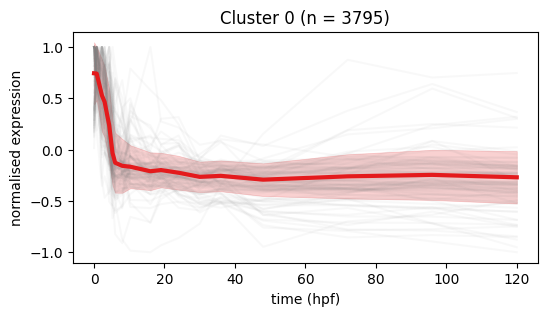

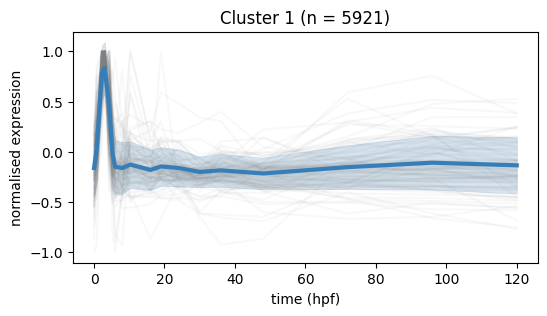

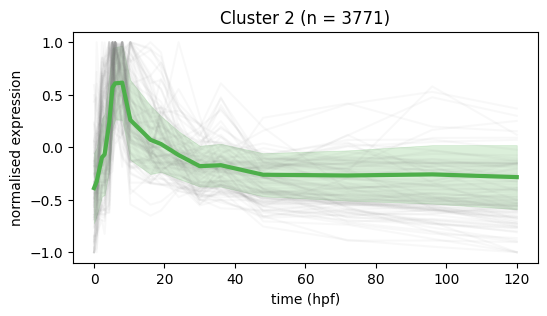

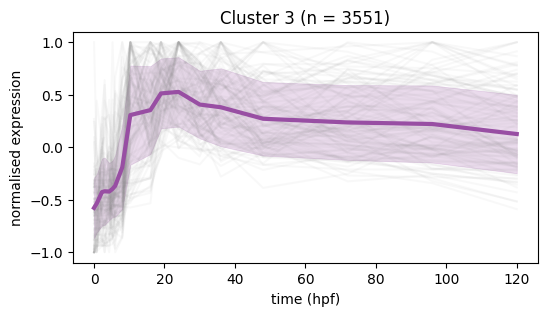

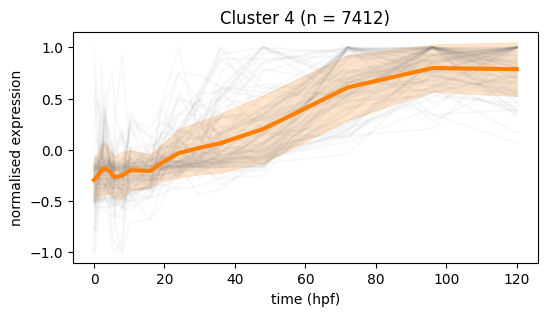

In [16]:
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
c = sns.color_palette("Set1",6)

cluster_data = xr.load_dataset("genes_clustered_White_h.nc").sel(time=slice(0, 120))

for cluster_id in range(5):
    genes = cluster_data.where(cluster_data.cluster == cluster_id, drop=True).y
    # Hestilow
    genes = (genes - genes.mean("time")) / abs(genes - genes.mean("time")).max("time")
    #genes = (genes - genes.min("time")) / (genes.max("time") - genes.min("time"))
    genes = genes.fillna(0)
    mean = genes.mean(dim="ensembl_gene_id")
    std = genes.std(dim="ensembl_gene_id")
    min = genes.min(dim="ensembl_gene_id")
    max = genes.max(dim="ensembl_gene_id")

    plt.figure(figsize=(6,3))
    for g in genes.ensembl_gene_id.values[:100]:
        plt.plot(genes.time, genes.sel(ensembl_gene_id=g), color='gray', alpha=0.05)
    plt.plot(genes.time, genes.mean(dim="ensembl_gene_id"),
            color=c[cluster_id], lw=3)
    plt.fill_between(genes.time, y1 = mean-std, y2=mean+std, lw=0.5, color=c[cluster_id], alpha=0.2)
    #plt.fill_between(genes.time, y1 = min, y2=max, lw=0.5, color=c[cluster_id], alpha=0.2)
    plt.xlabel("time (hpf)")
    plt.ylabel("normalised expression")
    plt.title(f"Cluster {cluster_id} (n = {len(genes.ensembl_gene_id)})")
    #plt.ylim(0, 6)
    plt.savefig(f"../figures/Cluster{cluster_id}_white_h.png")
    plt.show()


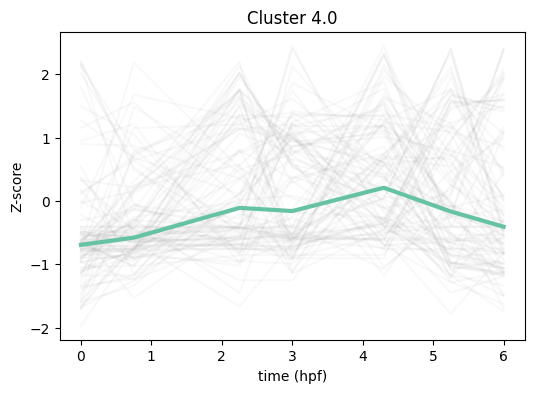

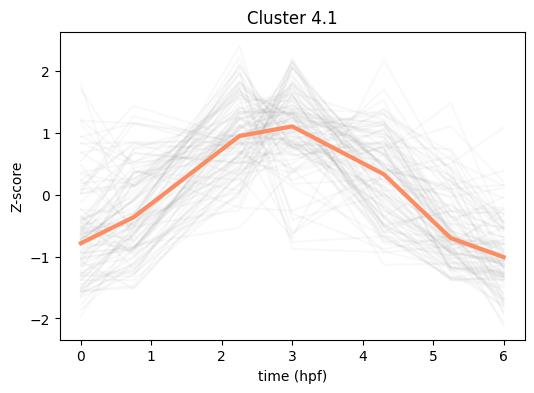

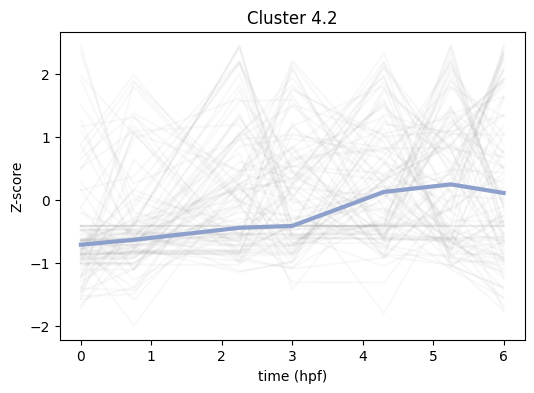

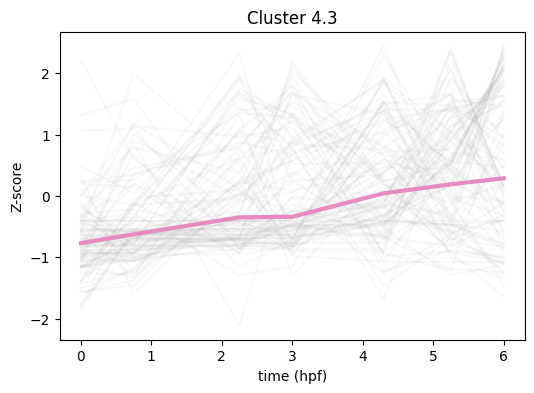

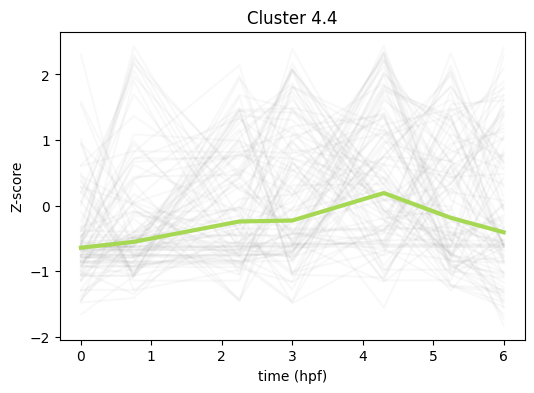

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
c = sns.color_palette("Set2", 6)

supercluster = 4

cluster_data = xr.load_dataset(f"genes_clustered_White_cluster{supercluster}.nc").sel(time=slice(0,6))
for cluster_id in range(5):
    genes = cluster_data.where(cluster_data.cluster == cluster_id, drop=True).y
    #genes = np.log2(genes.y + 1)
    genes = (genes - genes.mean("time")) / genes.std("time")
    #genes = genes.fillna(0)

    plt.figure(figsize=(6,4))
    for g in genes.ensembl_gene_id.values[:100]:
        plt.plot(genes.time, genes.sel(ensembl_gene_id=g), color='gray', alpha=0.05)
    plt.plot(genes.time, genes.median(dim="ensembl_gene_id"),
            color=c[cluster_id], lw=3)
    plt.xlabel("time (hpf)")
    plt.ylabel("Z-score")
    plt.title(f"Cluster {supercluster}.{cluster_id}")
    #plt.ylim(0, 6)
    #plt.savefig(f"../figures/Cluster{supercluster}.{cluster_id}_white.png")
    plt.show()

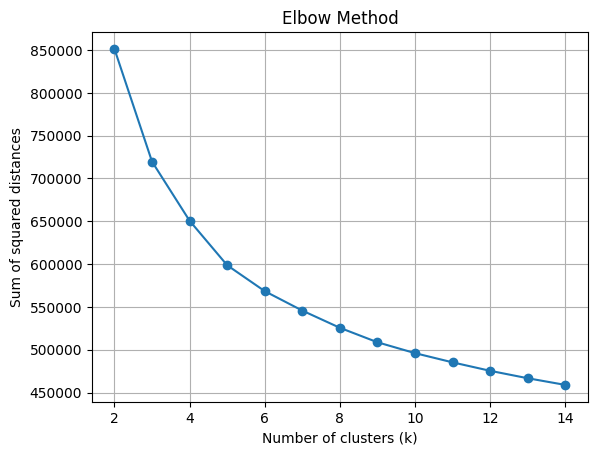

Elbow at k = 5


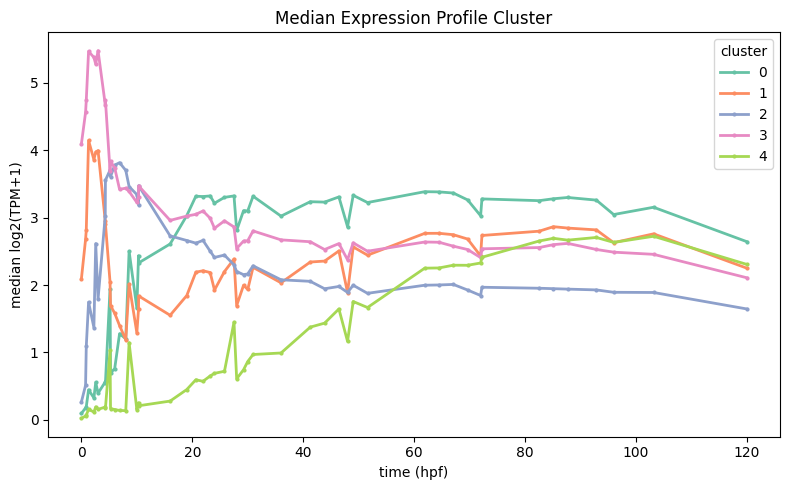

C:\Users\mgrho\AppData\Local\Temp\ipykernel_20712\3797845569.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


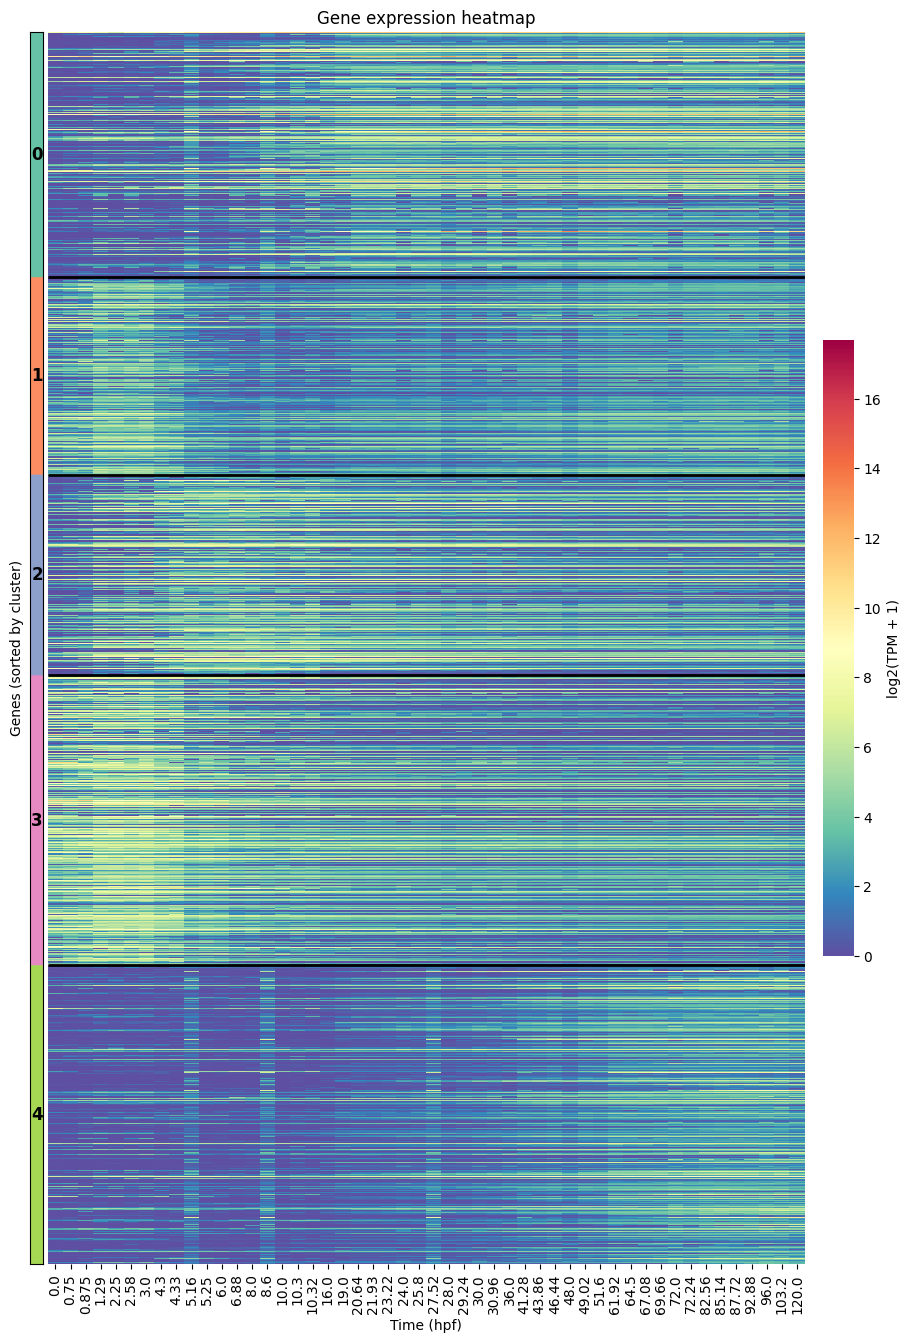

In [ ]:
import xarray as xr
data1 = xr.load_dataset("genes_tpms_white_pauli_JN_BK_mean_wSource_sampleSize.nc").mean(dim="source") 
kmean_clustering(data1, data_name="full_merged")

In [ ]:
import xarray as xr
import pandas as pd

for k in range(5):
    subcluster = k

    clusters = pd.read_csv("dataset_structure_white_cluster.csv")
    selected = clusters.loc[clusters["cluster"] == subcluster, "ensembl_gene_id"].values

    data1 = xr.load_dataset("white_dataset_mean.nc").sel(time=slice(0,120))
    data1 = data1.sel(ensembl_gene_id = selected)

    kmean_clustering(data1, data_name=f"White_cluster{subcluster}",  palette="Set2", k_cluster=5)

In [3]:
import xarray as xr
import pandas as pd

def filter_dataset(ds):
    
    num_positive = (ds['y'] > 0).sum(dim='time')
    max_tpm = ds['y'].max(dim='time')
    genes_to_keep = (num_positive >= 6) & (max_tpm > 1)
    ds_filtered = ds.sel(ensembl_gene_id=genes_to_keep)

    return ds_filtered

#data1 = xr.load_dataset("genes_tpms_white_pauli_JN_BK_median_wSource.nc").mean(dim="source") 
data1 = xr.load_dataset("white_dataset_mean.nc")
ds = filter_dataset(data1).copy()
list = ds.ensembl_gene_id.values.tolist()

# open file
with open(f'genes_clustered_white.txt', 'w+') as f:
    # write elements of list
    for items in list:
        f.write('%s\n' %items)  
    print("File written successfully")
# close the file
f.close() 

ds

File written successfully


<xarray.Dataset> Size: 4MB
Dimensions:          (time: 18, ensembl_gene_id: 24450)
Coordinates:
  * time             (time) float64 144B 0.0 0.75 2.25 3.0 ... 72.0 96.0 120.0
  * ensembl_gene_id  (ensembl_gene_id) object 196kB 'ENSDARG00000000001' ... ...
Data variables:
    y                (time, ensembl_gene_id) float64 4MB 2.782 0.3486 ... 0.0